In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import gensim

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
leetcode_questions_df = pd.read_csv('/content/drive/MyDrive/thesis/leetcode/part4 feature-engineering/leetcode_questions_df.csv')

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61834 entries, 0 to 61833
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            61834 non-null  object 
 1   country                             61834 non-null  object 
 2   contest_url                         61834 non-null  object 
 3   num_of_contest                      61834 non-null  int64  
 4   is_weekly                           61834 non-null  bool   
 5   rank                                61834 non-null  int64  
 6   score                               61834 non-null  int64  
 7   question_number                     61834 non-null  int64  
 8   question_language                   61834 non-null  object 
 9   question_code                       61834 non-null  object 
 10  number_of_lines                     61834 non-null  int64  
 11  names_set                           61834

In [4]:
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_language'] == 'java']
leetcode_questions_df = leetcode_questions_df[leetcode_questions_df['question_number'] > 2]
leetcode_questions_df = leetcode_questions_df.drop_duplicates(subset=['question_code'])

leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2999 entries, 20 to 61821
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            2999 non-null   object 
 1   country                             2999 non-null   object 
 2   contest_url                         2999 non-null   object 
 3   num_of_contest                      2999 non-null   int64  
 4   is_weekly                           2999 non-null   bool   
 5   rank                                2999 non-null   int64  
 6   score                               2999 non-null   int64  
 7   question_number                     2999 non-null   int64  
 8   question_language                   2999 non-null   object 
 9   question_code                       2999 non-null   object 
 10  number_of_lines                     2999 non-null   int64  
 11  names_set                           2999 non-n

In [5]:
leetcode_questions_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2999 entries, 20 to 61821
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   username                            2999 non-null   object 
 1   country                             2999 non-null   object 
 2   contest_url                         2999 non-null   object 
 3   num_of_contest                      2999 non-null   int64  
 4   is_weekly                           2999 non-null   bool   
 5   rank                                2999 non-null   int64  
 6   score                               2999 non-null   int64  
 7   question_number                     2999 non-null   int64  
 8   question_language                   2999 non-null   object 
 9   question_code                       2999 non-null   object 
 10  number_of_lines                     2999 non-null   int64  
 11  names_set                           2999 non-n

In [6]:
# Define rank thresholds
percantage = 10

high_rank_threshold = leetcode_questions_df['contest_finish_time_total_seconds'].quantile(percantage/100)
low_rank_threshold = leetcode_questions_df['contest_finish_time_total_seconds'].quantile(1 - percantage/100)


leetcode_questions_df["experienced_programmer"] = leetcode_questions_df["contest_finish_time_total_seconds"] <= low_rank_threshold


high_rank_df = leetcode_questions_df[leetcode_questions_df["contest_finish_time_total_seconds"] < high_rank_threshold]
low_rank_df = leetcode_questions_df[leetcode_questions_df["contest_finish_time_total_seconds"] > low_rank_threshold]


filtered_df = pd.concat([high_rank_df, low_rank_df])

filtered_df.reset_index(drop=True, inplace=True)

filtered_df["experienced_programmer"].value_counts()

,count
experienced_programmer,
True,300
False,300


In [7]:
filtered_df.drop(['num_of_contest','is_weekly','rank','score','global_rank_percentile','num_contests_participated','question_number'],axis=1, inplace=True)

In [8]:
filtered_df.drop(['contest_finish_time_total_seconds','question_finish_time_total_seconds','time_spent_per_question'],axis=1, inplace=True)

In [9]:
X=filtered_df.drop('experienced_programmer',axis=1)
Y=filtered_df.experienced_programmer.astype(int)

In [10]:
X_nontext=X.select_dtypes(exclude=['object'])
X_nontext.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   number_of_lines              600 non-null    int64  
 1   token_count                  600 non-null    int64  
 2   variables_count              600 non-null    int64  
 3   function_count               600 non-null    int64  
 4   loop_count                   600 non-null    int64  
 5   condition_count              600 non-null    int64  
 6   single_line_comment_density  600 non-null    float64
 7   multiline_comment_density    600 non-null    float64
 8   function_density             600 non-null    float64
 9   loop_density                 600 non-null    float64
 10  condition_density            600 non-null    float64
 11  comment_tokens_density       600 non-null    float64
 12  question_code_length         600 non-null    int64  
 13  has_camel_case      

In [11]:
X_train_nontext, X_test_nontext, y_train, y_test = train_test_split(X_nontext, Y, test_size=0.25, random_state=0,stratify=Y)

In [12]:
def print_test_confusion_matrix():
  disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred), display_labels=grid_search.classes_)

  fig, ax = plt.subplots(figsize=(15,10))
  disp.plot(ax=ax)

  plt.show()

# Decision Tree - All

In [13]:
baseline_model = Pipeline([('scaler',StandardScaler()),
                           ('classifier',DecisionTreeClassifier(random_state = 42))])

In [14]:
scores = cross_val_score(baseline_model, X_train_nontext, y_train, cv=5)
print("baseline model score: ",np.mean(scores))

baseline model score:  0.66


In [15]:
param_grid = {'classifier__max_depth' : [7, 9, 11, None],
              'classifier__min_samples_split' : [4, 8, 12],
              'classifier__criterion' :['gini', 'entropy']
             }

grid_search = GridSearchCV(estimator=baseline_model, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='f1_macro')

grid_search.fit(X_train_nontext, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score found: ", grid_search.best_score_)

best_dt = grid_search.best_estimator_
y_pred = best_dt.predict(X_test_nontext)
print("Test set F1 score: ", f1_score(y_test, y_pred, average='macro'))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters found:  {'classifier__criterion': 'entropy', 'classifier__max_depth': 7, 'classifier__min_samples_split': 8}
Best F1 score found:  0.6747942633008017
Test set F1 score:  0.6223700773242222


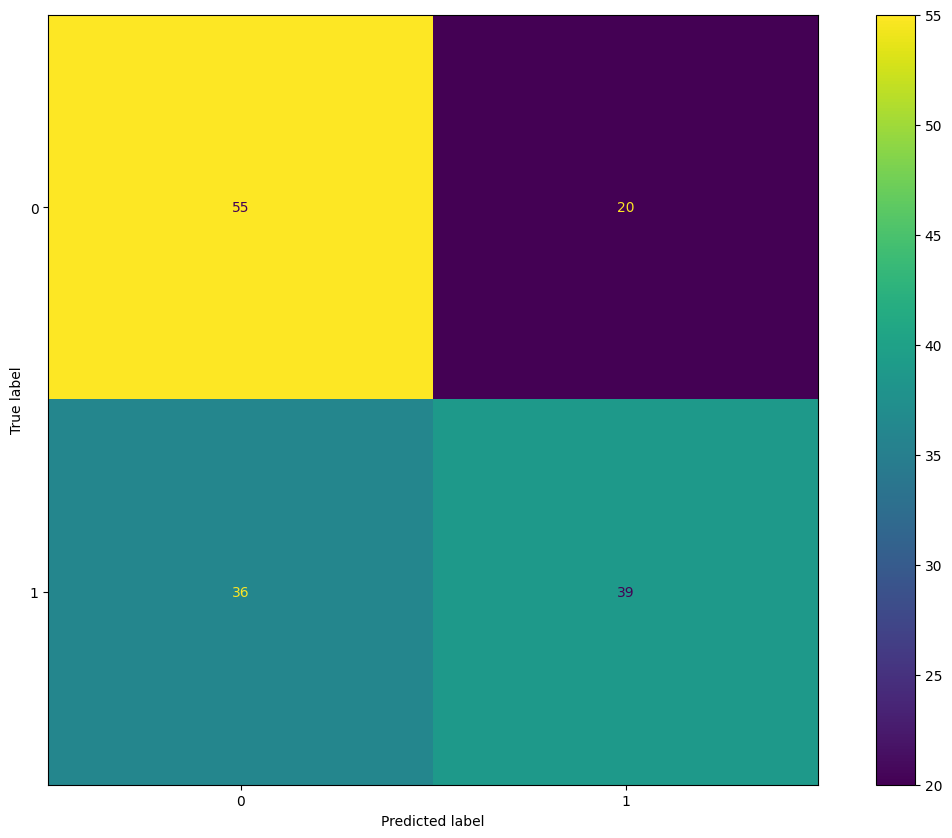

In [16]:
print_test_confusion_matrix()

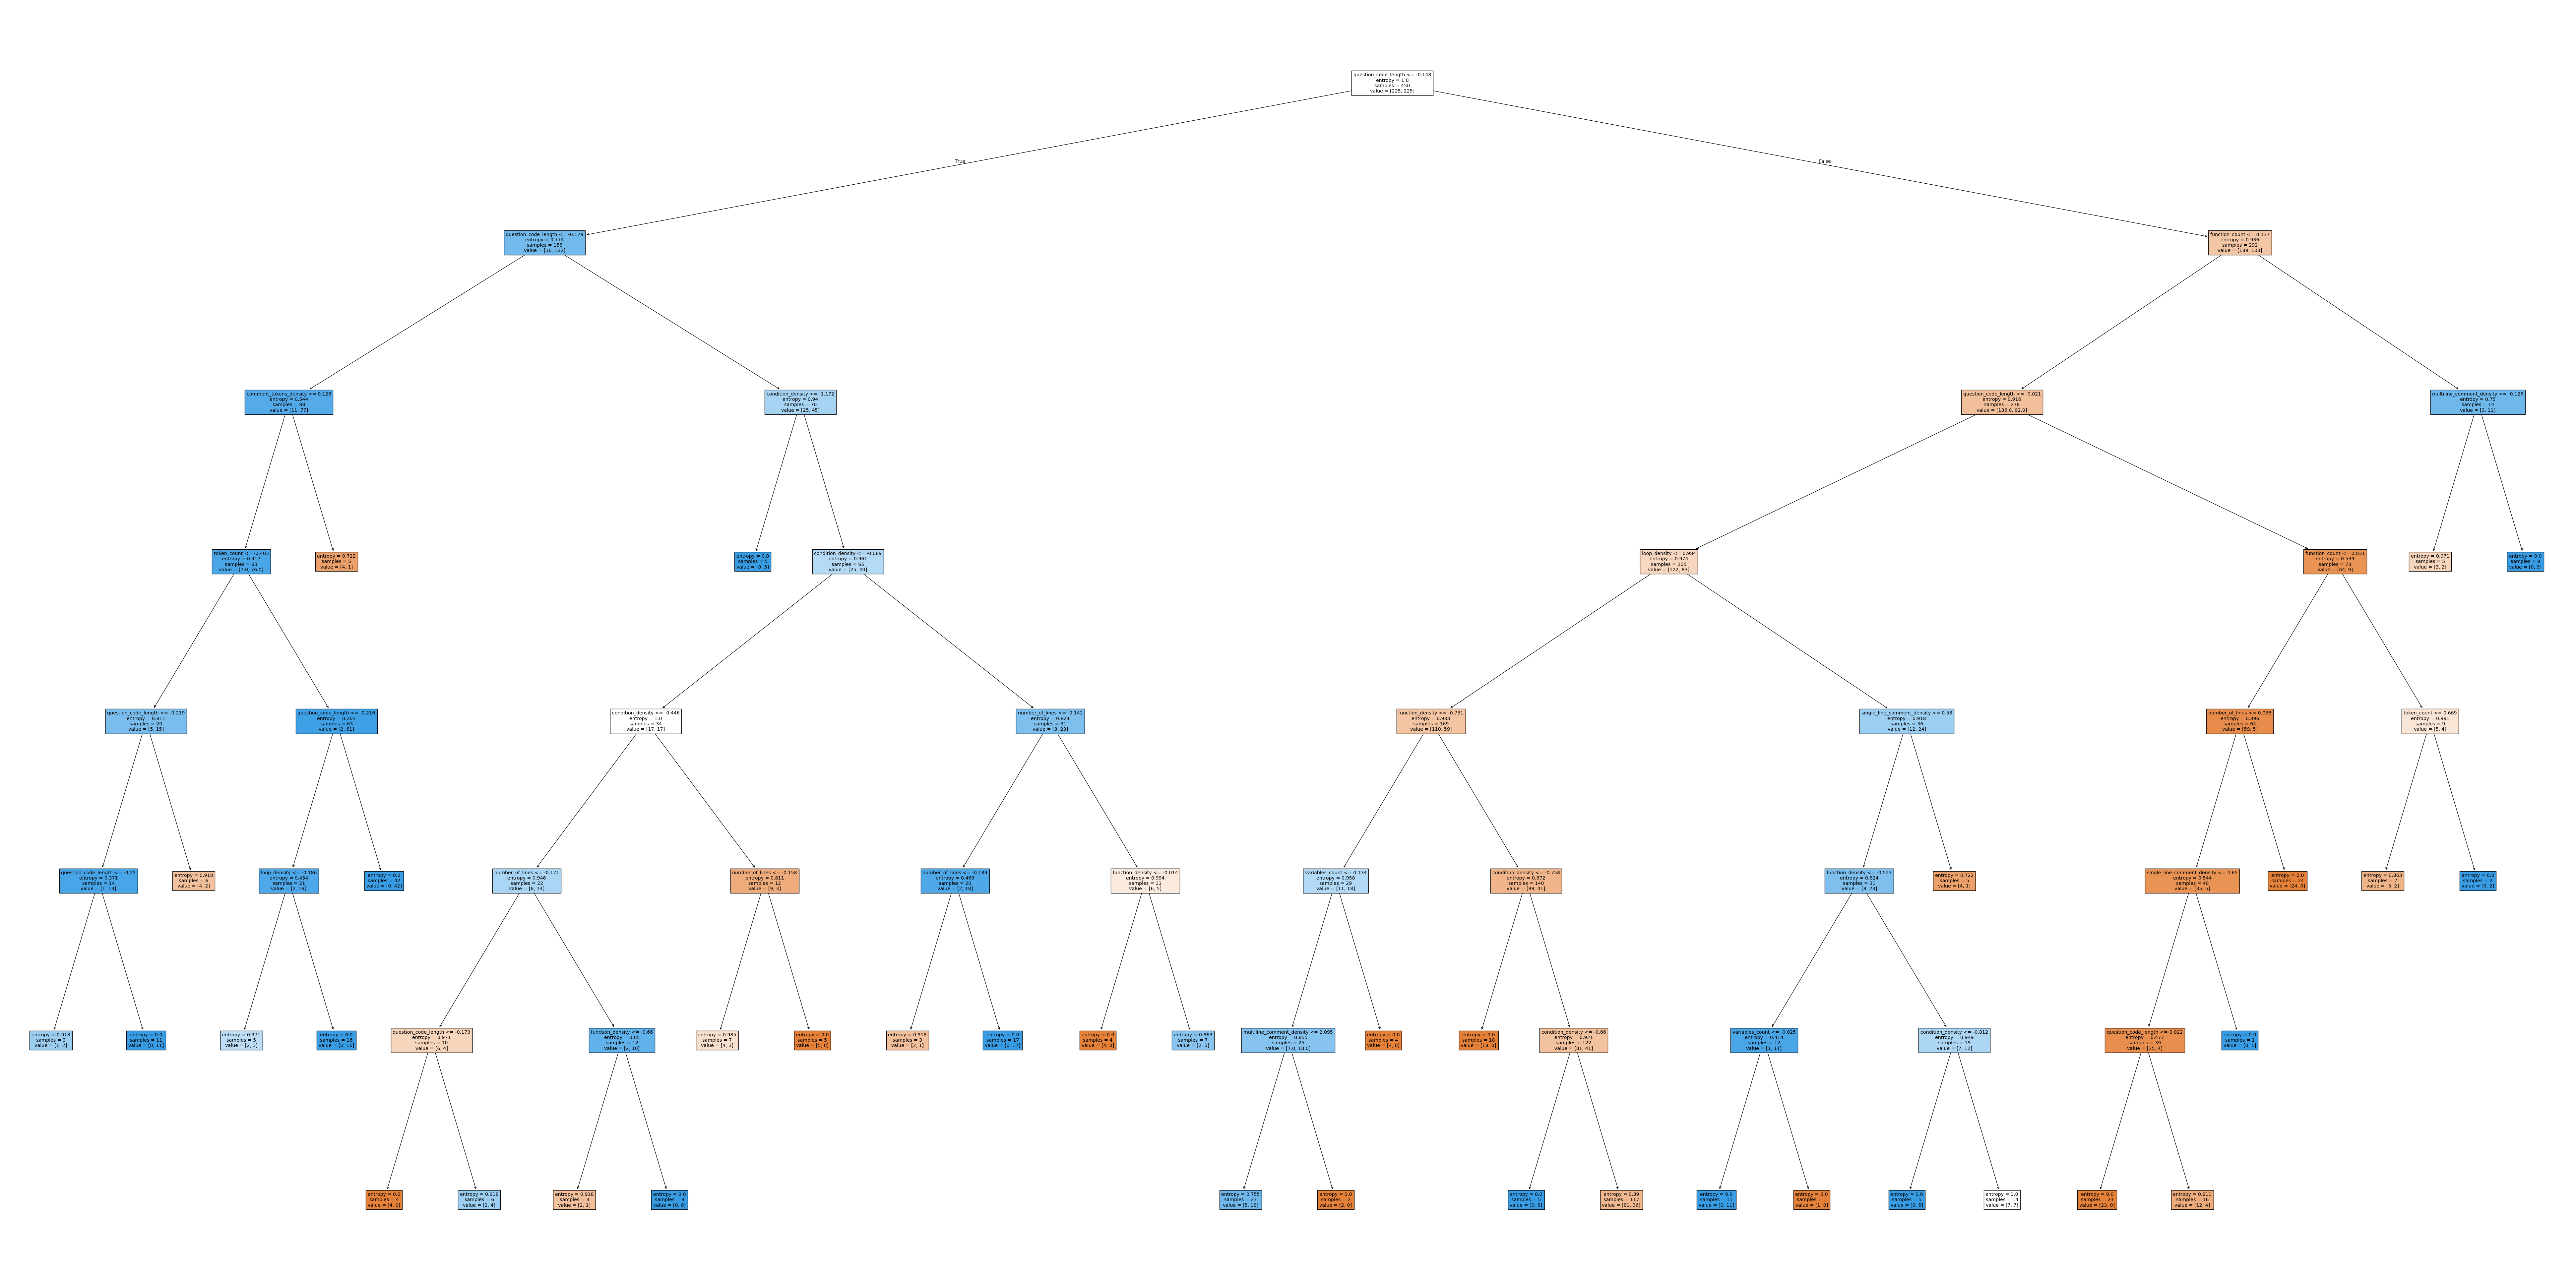

In [17]:
_, ax = plt.subplots(figsize=(100,50)) # Resize figure
plot_tree(best_dt['classifier'], filled=True, ax=ax, feature_names = X_train_nontext.columns.to_numpy())
plt.show()

# Random Forest

In [18]:
baseline_model = Pipeline([('scaler',StandardScaler()),
                           ('classifier',RandomForestClassifier())])

In [19]:
scores = cross_val_score(baseline_model, X_train_nontext, y_train, cv=5)
print("baseline model score: ",np.mean(scores))

baseline model score:  0.7133333333333335


In [20]:
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [10, 20, 30],
    'classifier__bootstrap': [True, False]
}

grid_search = GridSearchCV(estimator=baseline_model, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='f1_macro')

grid_search.fit(X_train_nontext, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score found: ", grid_search.best_score_)

best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test_nontext)
print("Test set F1 score: ", f1_score(y_test, y_pred, average='macro'))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters found:  {'classifier__bootstrap': False, 'classifier__max_depth': 30, 'classifier__n_estimators': 50}
Best F1 score found:  0.7256459122555191
Test set F1 score:  0.6785714285714286


# KNN

In [21]:
baseline_model = Pipeline([('scaler',StandardScaler()),
                           ('classifier',KNeighborsClassifier())])

In [22]:
scores = cross_val_score(baseline_model, X_train_nontext, y_train, cv=5)
print("baseline model score: ",np.mean(scores))

baseline model score:  0.6444444444444445


In [23]:
param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search = GridSearchCV(estimator=baseline_model, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='f1')

grid_search.fit(X_train_nontext, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score found: ", grid_search.best_score_)

best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test_nontext)
print("Test set F1 score: ", f1_score(y_test, y_pred, average='macro'))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters found:  {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 11, 'classifier__weights': 'uniform'}
Best F1 score found:  0.6794624650612237
Test set F1 score:  0.6664294609500089


# Support Vector Classifier

In [33]:
baseline_model = Pipeline([('scaler',StandardScaler()),
                           ('classifier',SVC(random_state = 42, probability=True))])

In [34]:
scores = cross_val_score(baseline_model, X_train_nontext, y_train, cv=5)
print("baseline model score: ",np.mean(scores))

baseline model score:  0.6599999999999999


In [35]:
param_grid = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': ['scale', 'auto'],
    'classifier__kernel': ['linear', 'poly', 'rbf', 'sigmoid']
}

grid_search = GridSearchCV(estimator=baseline_model, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='f1_macro')

grid_search.fit(X_train_nontext, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score found: ", grid_search.best_score_)

best_svc = grid_search.best_estimator_
y_pred = best_svc.predict(X_test_nontext)
print("Test set F1 score: ", f1_score(y_test, y_pred, average='macro'))

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters found:  {'classifier__C': 100, 'classifier__gamma': 'scale', 'classifier__kernel': 'linear'}
Best F1 score found:  0.7001023177404369
Test set F1 score:  0.6951081801346041


In [36]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.57      0.66        75
           1       0.66      0.83      0.73        75

    accuracy                           0.70       150
   macro avg       0.71      0.70      0.70       150
weighted avg       0.71      0.70      0.70       150

